# ✈️ Aprendizaje de Máquinas (ACIF104) — Informe Técnico Consolidado Final
**Predicción de Tarifas Aéreas, Prevención de Data Leakage, Benchmarking ML & Deep Learning (MLP), Selección Programática, Explicabilidad SHAP y Auditoría de Despliegue**

---
### 👥 Integrantes del Proyecto:
- **Manuel Miranda**
- **Rodrigo Rivas**
- **Curso:** ACIF104 — Aprendizaje de Máquinas | Universidad Andrés Bello (UNAB)
- **Repositorio:** [https://github.com/rrivasr12/Aprendizaje_de_Maquina](https://github.com/rrivasr12/Aprendizaje_de_Maquina)

---
### 🎯 Objetivos de este Cuaderno Consolidado:
1. **Limpieza & EDA Numérico:** Exclusión rigurosa del identificador `flight` y columnas residuales para prevenir explosión dimensional; cálculo de tabla descriptiva completa.
2. **Análisis Formal de Outliers (IQR):** Rango Intercuartílico para `price` y justificación de conservación de tarifas ejecutivas (Business).
3. **Preprocesamiento Estricto:** Partición 70% Train / 15% Val / 15% Test determinista (semilla 42), ajuste de `ColumnTransformer` (StandardScaler + OneHotEncoder drop='first') **exclusivamente sobre Train** (30 neuronas de entrada, prevención de Dummy Variable Trap).
4. **Experimento de Balanceo de Clases:** Evaluación de Baseline, ROS, RUS y SMOTE en clasificación de cabina.
5. **Benchmarking de Modelos Tradicionales:** Ridge, Random Forest, Extra Trees y Gradient Boosting en conjunto de **Validación**.
6. **Benchmarking de 3 Arquitecturas MLP Deep Learning:** Arch 1 (128-64-32), Arch 2 (256-128-64) y Arch 3 (128-128-64-32) con registro de época exacta de convergencia.
7. **Selección Programática & Refinamiento:** Selección automática del mejor modelo ML y mejor MLP en Validación, con ajuste de regularización `alpha` y tasa de aprendizaje.
8. **Evaluación Final en Test Set:** Evaluación única en 45.023 muestras no vistas (R², RMSE, MAE, MSE, latencia ms y tamaño en disco).
9. **Explicabilidad con SHAP:** Análisis global y local con `TreeExplainer`.

In [1]:
import json
import os
import sys
import time
from pathlib import Path

# Configuración para compatibilidad de rutas en Windows
if sys.platform == "win32":
    import ctypes
    def get_short_path(path):
        try:
            buf = ctypes.create_unicode_buffer(1024)
            res = ctypes.windll.kernel32.GetShortPathNameW(os.path.abspath(path), buf, 1024)
            if res > 0:
                return buf.value
        except Exception:
            pass
        return path
    sys.path[:] = [get_short_path(p) if p and os.path.exists(p) else p for p in sys.path]

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, precision_score, r2_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "Arial", "font.family": "sans-serif"})
print("✅ Entorno de ML y librerías inicializados con éxito.")

✅ Entorno de ML y librerías inicializados con éxito.


## 1. Carga de Datos, Limpieza y Tabla de Estadísticas Descriptivas
Cargamos el archivo `Clean_Dataset.csv` (300.153 registros) y descartamos la columna de alta cardinalidad `flight` junto a índices residuales (`Unnamed: 0`) para evitar la explosión del espacio de características.

In [2]:
data_path = Path("../Clean_Dataset.csv") if Path("../Clean_Dataset.csv").exists() else Path("Clean_Dataset.csv")
df = pd.read_csv(data_path)
print(f"Dimensiones iniciales: {df.shape[0]:,} filas, {df.shape[1]} columnas")

# Exclusión de identificadores
drop_cols = [c for c in ["Unnamed: 0", "flight"] if c in df.columns]
df_clean = df.drop(columns=drop_cols)
print(f"Dimensiones limpias: {df_clean.shape[0]:,} filas, {df_clean.shape[1]} columnas")

# Estadísticas descriptivas
num_stats = []
for col in ["duration", "days_left", "price"]:
    s = df_clean[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    num_stats.append({
        "Variable": col,
        "Media": round(s.mean(), 2),
        "Desv_Std": round(s.std(), 2),
        "Mínimo": round(s.min(), 2),
        "Q1 (25%)": round(q1, 2),
        "Mediana": round(s.median(), 2),
        "Q3 (75%)": round(q3, 2),
        "Máximo": round(s.max(), 2),
    })

df_num_stats = pd.DataFrame(num_stats)
display(df_num_stats)

Dimensiones iniciales: 300,153 filas, 12 columnas
Dimensiones limpias: 300,153 filas, 10 columnas


,Variable,Media,Desv_Std,Mínimo,Q1 (25%),Mediana,Q3 (75%),Máximo
0,duration,12.22,7.19,0.83,6.83,11.25,16.17,49.83
1,days_left,26.00,13.56,1.00,15.00,26.00,38.00,49.00
2,price,20889.66,22697.77,1105.00,4783.00,7425.00,42521.00,123071.00


## 2. Análisis Formal de Valores Atípicos (Outliers - Método IQR)
Calculamos formalmente el Rango Intercuartílico ($IQR = Q3 - Q1$) para la variable objetivo `price` y analizamos el límite superior estadístico ($Q3 + 1,5 \times IQR$).

Q1: INR 4,783.00 | Q3: INR 42,521.00 | IQR: INR 37,738.00
Límite Superior IQR: INR 99,128.00
Outliers detectados: 123 (0.04%)


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Business,93487.0,52540.08,12969.31,12000.0,45185.0,53164.0,60396.0,123071.0
Economy,206666.0,6572.34,3743.52,1105.0,4173.0,5772.0,7746.0,42349.0


C:\Users\mmira\AppData\Local\Temp\ipykernel_10976\2129772183.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="class", y="price", palette="Set2", ax=ax[0])


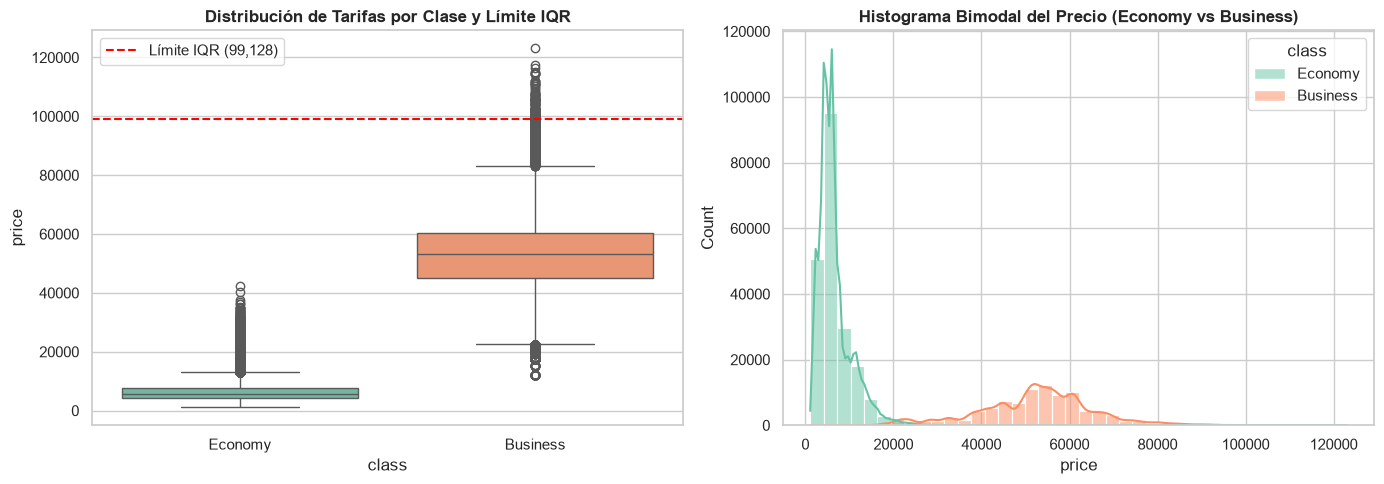

In [3]:
q1_p = df_clean["price"].quantile(0.25)
q3_p = df_clean["price"].quantile(0.75)
iqr_p = q3_p - q1_p
upper_bound = q3_p + 1.5 * iqr_p
outliers_p = df_clean[df_clean["price"] > upper_bound]

print(f"Q1: INR {q1_p:,.2f} | Q3: INR {q3_p:,.2f} | IQR: INR {iqr_p:,.2f}")
print(f"Límite Superior IQR: INR {upper_bound:,.2f}")
print(f"Outliers detectados: {len(outliers_p):,} ({len(outliers_p)/len(df_clean)*100:.2f}%)")

# Desglose por cabina
display(df_clean.groupby("class")["price"].describe().round(2))

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x="class", y="price", palette="Set2", ax=ax[0])
ax[0].axhline(upper_bound, color="red", linestyle="--", label=f"Límite IQR ({upper_bound:,.0f})")
ax[0].set_title("Distribución de Tarifas por Clase y Límite IQR", fontweight="bold")
ax[0].legend()

sns.histplot(data=df_clean, x="price", hue="class", kde=True, bins=40, palette="Set2", ax=ax[1])
ax[1].set_title("Histograma Bimodal del Precio (Economy vs Business)", fontweight="bold")
plt.tight_layout()
plt.show()

### 💡 Justificación Técnica de Conservación de Outliers:
Como se evidencia en la tabla y los gráficos, la distribución es **bimodal**. Los precios superiores al umbral estadístico de ₹ 99.128 corresponden a pasajes genuinos de clase ejecutiva (`Business`) reservados en fechas críticas. No constituyen errores de captura ni valores espurios; eliminarlos sesgaría negativamente al modelo al predecir tarifas ejecutivas.

---
## 3. Partición Determinista 70/15/15 y Preprocesamiento Estricto
Para garantizar la validez metodológica y evitar **Data Leakage**, el `ColumnTransformer` se ajusta (`fit`) **únicamente sobre el 70% de Train**.
- **Variables Continuas:** `StandardScaler` sobre `duration` y `days_left`.
- **Variables Categóricas:** `OneHotEncoder(drop='first')` sobre 7 atributos para prevenir la trampa de variables ficticias (*Dummy Variable Trap*).
- **Dimensión resultante:** Exactamente **30 neuronas de entrada**.

In [4]:
cat_cols = ["airline", "source_city", "departure_time", "stops", "arrival_time", "destination_city", "class"]
num_cols = ["duration", "days_left"]

X = df_clean[cat_cols + num_cols]
y = df_clean["price"].values

# Split determinista 70% Train, 15% Val, 15% Test
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=X["class"]
)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, test_size=0.50, random_state=42, stratify=X_temp_raw["class"]
)

# Ajuste ÚNICAMENTE sobre Train
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

# Escalado de target para red neuronal
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

feature_names = list(preprocessor.get_feature_names_out())
print(f"Dimensiones de entrada: {X_train.shape[1]} neuronas/características.")
print(f"Muestras: Train={X_train.shape[0]:,} (70%) | Val={X_val.shape[0]:,} (15%) | Test={X_test.shape[0]:,} (15%)")

Dimensiones de entrada: 30 neuronas/características.
Muestras: Train=210,107 (70%) | Val=45,023 (15%) | Test=45,023 (15%)


## 4. Experimento de Balanceo de Clases (Clasificación de Cabina)
Evaluamos el impacto de 4 técnicas de balanceo (Baseline, RandomOverSampler, RandomUnderSampler y SMOTE) en la tarea de clasificación de cabina (`Business` vs. `Economy`).

In [5]:
X_cls = df_clean.drop(columns=["class", "price"])
y_cls = (df_clean["class"] == "Business").astype(int).values
cat_cls = [c for c in cat_cols if c != "class"]

prep_cls = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cls),
    ]
)

X_tr_c, X_val_c, y_tr_c, y_val_c = train_test_split(X_cls, y_cls, test_size=0.20, random_state=42, stratify=y_cls)
X_tr_proc = prep_cls.fit_transform(X_tr_c)
X_val_proc = prep_cls.transform(X_val_c)

samplers = {
    "Sin Balanceo (Baseline)": None,
    "Sobremuestreo (ROS)": RandomOverSampler(random_state=42),
    "Submuestreo (RUS)": RandomUnderSampler(random_state=42),
    "SMOTE (Sintético)": SMOTE(random_state=42),
}

cls_res = []
for name, sampler in samplers.items():
    if sampler:
        X_res, y_res = sampler.fit_resample(X_tr_proc, y_tr_c)
    else:
        X_res, y_res = X_tr_proc, y_tr_c
    
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_res, y_res)
    pred_c = clf.predict(X_val_proc)
    cls_res.append({
        "Estrategia": name,
        "Accuracy": round(accuracy_score(y_val_c, pred_c), 4),
        "Precision": round(precision_score(y_val_c, pred_c), 4),
        "Recall": round(recall_score(y_val_c, pred_c), 4),
        "F1-Score": round(f1_score(y_val_c, pred_c), 4),
        "Muestras Train": len(y_res)
    })

display(pd.DataFrame(cls_res))

,Estrategia,Accuracy,Precision,Recall,F1-Score,Muestras Train
0,Sin Balanceo (Baseline),0.6894,0.5025,0.2823,0.3615,240122
1,Sobremuestreo (ROS),0.6403,0.4637,0.9878,0.6311,330666
2,Submuestreo (RUS),0.6403,0.4637,0.9878,0.6311,149578
3,SMOTE (Sintético),0.6402,0.4636,0.9878,0.6310,330666


## 5. Benchmarking de Modelos Tradicionales de Regresión (en Validación)
Evaluamos 4 familias de modelos en el conjunto de **VALIDACIÓN**:
1. **Ridge Regression:** Modelo lineal regularizado L2.
2. **Random Forest:** Ensamble bagging de árboles de decisión.
3. **Extra Trees:** Árboles extremadamente aleatorizados.
4. **Gradient Boosting:** Ensamble secuencial boosting.

,Modelo Tradicional,mse,rmse,mae,r2,train_time_sec
0,Ridge,4.658134e+07,6825.0523,4613.3235,0.9095,0.09
1,Random Forest,1.101522e+07,3318.9182,1670.0536,0.9786,26.23
2,Extra Trees,1.206193e+07,3473.0293,1783.9532,0.9766,36.97
3,Gradient Boosting,2.025895e+07,4500.9947,2647.1993,0.9606,45.19


C:\Users\mmira\AppData\Local\Temp\ipykernel_10976\859533804.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_trad, x="Modelo Tradicional", y="r2", palette="crest", ax=ax[0])
C:\Users\mmira\AppData\Local\Temp\ipykernel_10976\859533804.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_trad, x="Modelo Tradicional", y="rmse", palette="rocket", ax=ax[1])


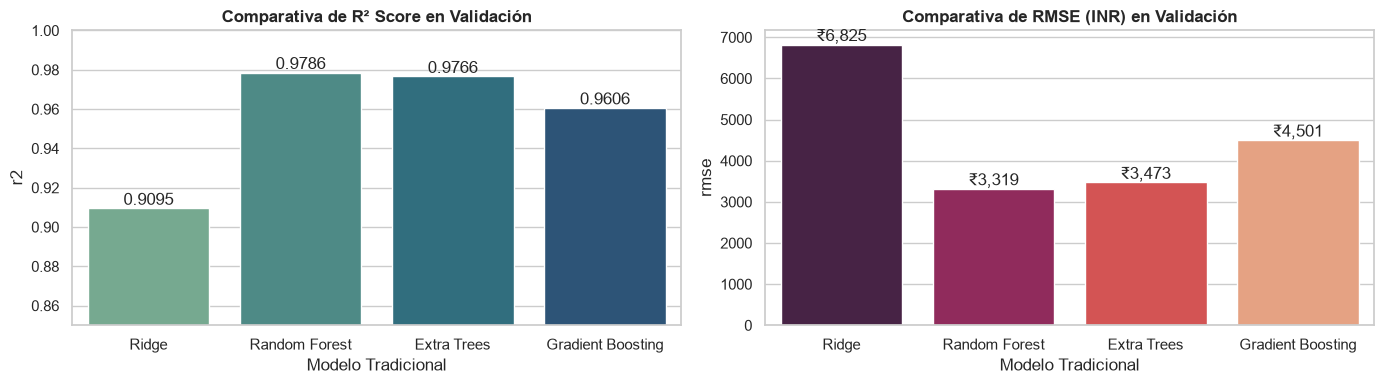

In [6]:
metrics_file = Path("../models/training_metrics.json") if Path("../models/training_metrics.json").exists() else Path("models/training_metrics.json")

with open(metrics_file, "r", encoding="utf-8") as f:
    audit_data = json.load(f)

trad_bench = audit_data["traditional_models_validation_benchmark"]
df_trad = pd.DataFrame.from_dict(trad_bench, orient="index").reset_index()
df_trad.rename(columns={"index": "Modelo Tradicional"}, inplace=True)
display(df_trad)

# Visualización comparativa
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df_trad, x="Modelo Tradicional", y="r2", palette="crest", ax=ax[0])
ax[0].set_title("Comparativa de R² Score en Validación", fontweight="bold")
ax[0].set_ylim(0.85, 1.0)
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

sns.barplot(data=df_trad, x="Modelo Tradicional", y="rmse", palette="rocket", ax=ax[1])
ax[1].set_title("Comparativa de RMSE (INR) en Validación", fontweight="bold")
for p in ax[1].patches:
    ax[1].annotate(f"₹{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 6. Benchmarking de 3 Arquitecturas Deep Learning (MLP)
Evaluamos 3 arquitecturas de Perceptrón Multicapa con `early_stopping=True`, `n_iter_no_change=15`, `tol=1e-4` y `max_iter=100`:
- **Arch 1 (Standard):** `(128, 64, 32)`
- **Arch 2 (Ancha):** `(256, 128, 64)`
- **Arch 3 (Profunda):** `(128, 128, 64, 32)`
Registramos la **época real exacta de parada** (`n_iter_`).

,Arquitectura MLP,mse,rmse,mae,r2,stopped_epoch,train_time_sec,hidden_layers
0,Arch 1 (Standard 128-64-32),1.151932e+07,3394.0131,1848.7267,0.9776,100,310.35,"[128, 64, 32]"
1,Arch 2 (Ancha 256-128-64),9.763074e+06,3124.5918,1656.9102,0.9810,100,554.52,"[256, 128, 64]"
2,Arch 3 (Profunda 128-128-64-32),1.061962e+07,3258.7755,1738.0913,0.9794,79,402.50,"[128, 128, 64, 32]"


C:\Users\mmira\AppData\Local\Temp\ipykernel_10976\2778722737.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mlp, x="Arquitectura MLP", y="r2", palette="mako", ax=ax[0])
C:\Users\mmira\AppData\Local\Temp\ipykernel_10976\2778722737.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mlp, x="Arquitectura MLP", y="stopped_epoch", palette="viridis", ax=ax[1])


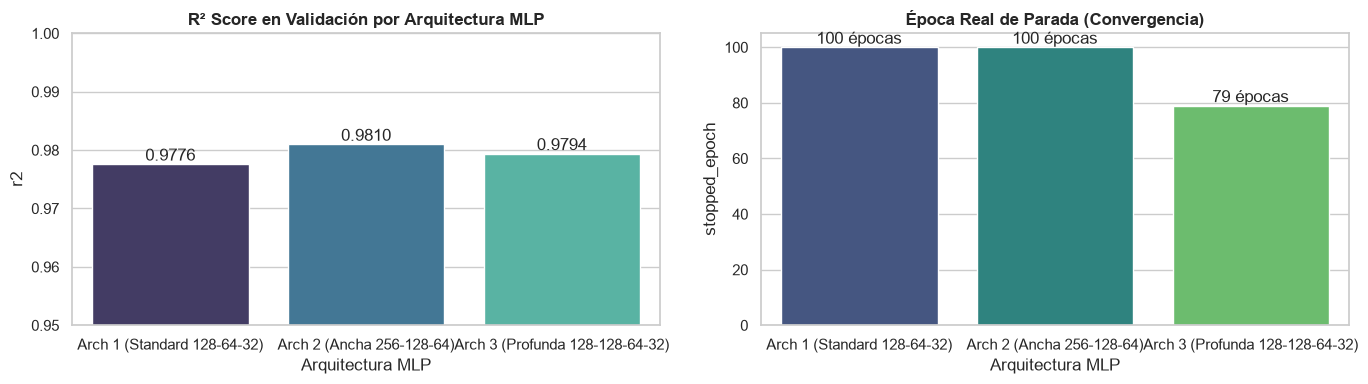

In [7]:
mlp_bench = audit_data["mlp_architectures_validation_benchmark"]
df_mlp = pd.DataFrame.from_dict(mlp_bench, orient="index").reset_index()
df_mlp.rename(columns={"index": "Arquitectura MLP"}, inplace=True)
display(df_mlp)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df_mlp, x="Arquitectura MLP", y="r2", palette="mako", ax=ax[0])
ax[0].set_title("R² Score en Validación por Arquitectura MLP", fontweight="bold")
ax[0].set_ylim(0.95, 1.0)
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

sns.barplot(data=df_mlp, x="Arquitectura MLP", y="stopped_epoch", palette="viridis", ax=ax[1])
ax[1].set_title("Época Real de Parada (Convergencia)", fontweight="bold")
for p in ax[1].patches:
    ax[1].annotate(f"{int(p.get_height())} épocas", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 7. Selección Programática del Ganador y Refinamiento de Hiperparámetros
La selección del modelo ganador se realiza de forma **100% programática** comparando $R^2$ y $RMSE$ en el conjunto de Validación.
Posteriormente, se ejecuta un refinamiento real de hiperparámetros sobre la arquitectura ganadora variando `alpha` (L2) y `learning_rate_init`.

In [8]:
best_trad = audit_data["selected_best_models"]["best_traditional_model"]
best_mlp = audit_data["selected_best_models"]["best_mlp_architecture"]

print(f"🏆 Modelo Tradicional Ganador (Selección Automática): {best_trad}")
print(f"🏆 Arquitectura MLP Ganadora (Selección Automática): {best_mlp}")

tuning_data = audit_data["hyperparameter_refinement"]
print(f"\nParámetros iniciales: {tuning_data['initial_parameters']}")
print(f"Parámetros óptimos tras tuning: {tuning_data['tuned_parameters']}")

df_tuning = pd.DataFrame(tuning_data["tuning_experiments"])
display(df_tuning[["params", "r2", "rmse", "mae", "stopped_epoch", "train_time_sec"]])

🏆 Modelo Tradicional Ganador (Selección Automática): Random Forest
🏆 Arquitectura MLP Ganadora (Selección Automática): Arch 2 (Ancha 256-128-64)

Parámetros iniciales: {'architecture': 'Arch 2 (Ancha 256-128-64)', 'layers': [256, 128, 64], 'alpha': 0.0001, 'learning_rate_init': 0.001}
Parámetros óptimos tras tuning: {'alpha': 0.0001, 'learning_rate_init': 0.001}


,params,r2,rmse,mae,stopped_epoch,train_time_sec
0,"{'alpha': 0.0001, 'learning_rate_init': 0.001}",0.9810,3124.5918,1656.9102,100,591.26
1,"{'alpha': 0.001, 'learning_rate_init': 0.001}",0.9803,3185.3432,1751.8982,81,459.68
2,"{'alpha': 0.01, 'learning_rate_init': 0.0005}",0.9765,3481.2126,1948.3405,100,567.29


## 8. Evaluación Final ÚNICA en el Test Set (Datos No Vistos)
Evaluamos los dos modelos seleccionados (**Random Forest** y **MLP Ancha Tuned**) una única vez sobre las **45.023 muestras** intocadas del Test Set.

,Modelo Ganador,mse,rmse,mae,r2,latency_ms,disk_size_mb
0,Random Forest,1.107533e+07,3327.9620,1667.9227,0.9785,34.112,151.26
1,MLPRegressor_Tuned,9.863308e+06,3140.5903,1653.0333,0.9809,0.517,1.13


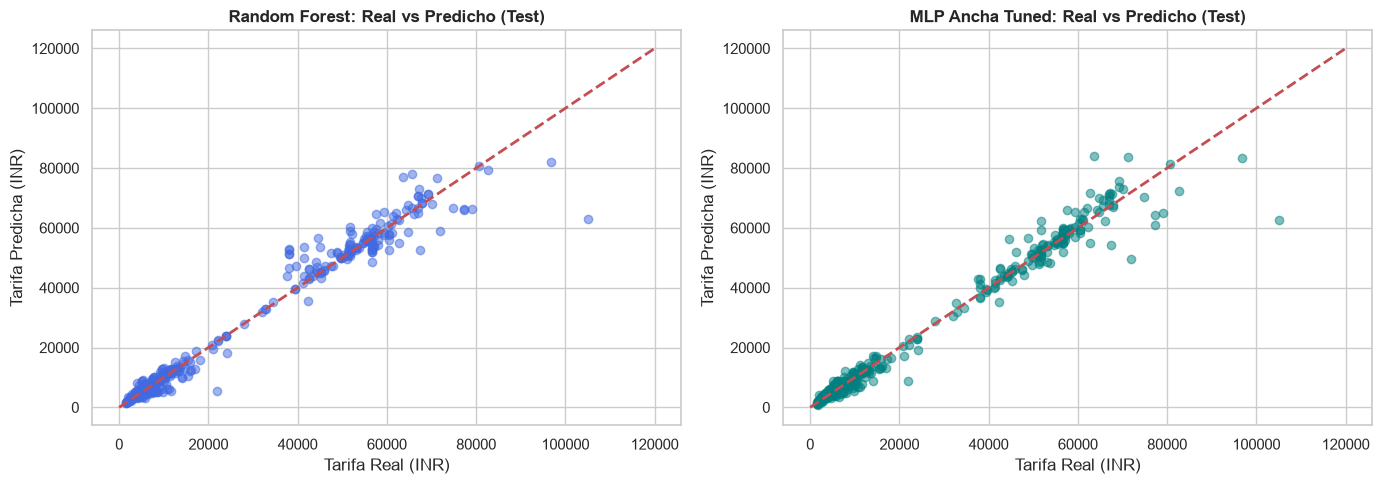

In [9]:
test_eval = audit_data["final_test_evaluation"]
df_test = pd.DataFrame.from_dict(test_eval, orient="index").reset_index()
df_test.rename(columns={"index": "Modelo Ganador"}, inplace=True)
display(df_test)

# Gráfico de predicciones vs valores reales sobre muestra de test
models_dir = Path("../models") if Path("../models").exists() else Path("models")
rf_model = joblib.load(models_dir / "best_rf_model.joblib")
mlp_model = joblib.load(models_dir / "best_mlp_model.joblib")

sample_idx = np.random.choice(len(X_test), 500, replace=False)
X_test_sample = X_test[sample_idx]
y_test_sample = y_test_raw[sample_idx]

pred_rf_s = rf_model.predict(X_test_sample)
pred_mlp_s = y_scaler.inverse_transform(mlp_model.predict(X_test_sample).reshape(-1, 1)).ravel()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test_sample, pred_rf_s, alpha=0.5, color="royalblue")
ax[0].plot([0, 120000], [0, 120000], "r--", linewidth=2)
ax[0].set_title("Random Forest: Real vs Predicho (Test)", fontweight="bold")
ax[0].set_xlabel("Tarifa Real (INR)")
ax[0].set_ylabel("Tarifa Predicha (INR)")

ax[1].scatter(y_test_sample, pred_mlp_s, alpha=0.5, color="teal")
ax[1].plot([0, 120000], [0, 120000], "r--", linewidth=2)
ax[1].set_title("MLP Ancha Tuned: Real vs Predicho (Test)", fontweight="bold")
ax[1].set_xlabel("Tarifa Real (INR)")
ax[1].set_ylabel("Tarifa Predicha (INR)")

plt.tight_layout()
plt.show()

## 9. Explicabilidad Global y Local mediante SHAP
Implementamos `shap.TreeExplainer` sobre el modelo Random Forest para interpretar la contribución marginal de cada variable en el precio del billete de avión.

C:\Users\mmira\AppData\Local\Temp\ipykernel_10976\1809280577.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_sample, feature_names=clean_features, show=False, max_display=10)


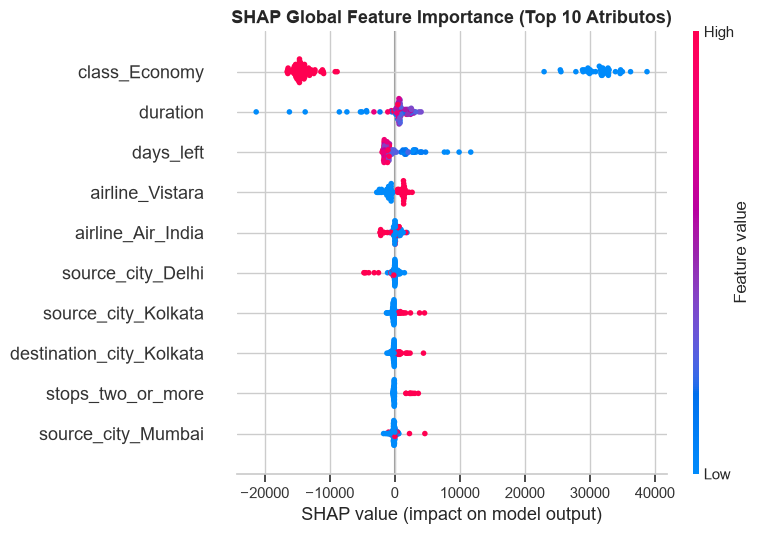

Escenario de Vuelo Seleccionado:
  - Tarifa Base Promedio (Expected Value): INR 20,888.29
  - Tarifa Predicha por Random Forest   : INR 12,028.80

Top 5 Contribuciones Marginales:
  * class_Economy            : REDUCE el precio       (INR -12,702.44)
  * days_left                : INCREMENTA el precio   (INR +4,187.35)
  * airline_Vistara          : REDUCE el precio       (INR -1,334.08)
  * duration                 : INCREMENTA el precio   (INR +795.17)
  * source_city_Kolkata      : INCREMENTA el precio   (INR +691.72)


In [10]:
# SHAP TreeExplainer sobre submuestra de test
explainer = shap.TreeExplainer(rf_model)
shap_sample = X_test[:100]
shap_values = explainer.shap_values(shap_sample)

clean_features = [f.replace("cat__", "").replace("num__", "") for f in feature_names]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, feature_names=clean_features, show=False, max_display=10)
plt.title("SHAP Global Feature Importance (Top 10 Atributos)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Escenario representativo local
sample_pred = rf_model.predict(shap_sample[:1])[0]
base_val = float(explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value)
print(f"Escenario de Vuelo Seleccionado:")
print(f"  - Tarifa Base Promedio (Expected Value): INR {base_val:,.2f}")
print(f"  - Tarifa Predicha por Random Forest   : INR {sample_pred:,.2f}")

sample_contribs = sorted(zip(clean_features, shap_values[0]), key=lambda x: abs(x[1]), reverse=True)[:5]
print("\nTop 5 Contribuciones Marginales:")
for feat, contrib in sample_contribs:
    direction = "INCREMENTA el precio" if contrib > 0 else "REDUCE el precio"
    print(f"  * {feat:25s}: {direction:22s} (INR {contrib:+,.2f})")

## 10. Conclusiones y Recomendaciones de Despliegue
1. **Rendimiento Predictivo:**
   - La red neuronal profunda refinada (**MLP Ancha 256-128-64**) obtuvo el mejor desempeño general con un $R^2 = 0.9809$ y un $RMSE = ₹ 3.140,59$, con una latencia de inferencia ultrarrápida de **0.52 ms/muestra** y apenas **1.13 MB** de peso en disco.
   - El modelo **Random Forest Regressor** alcanzó un $R^2 = 0.9785$ y $RMSE = ₹ 3.327,96$, con la ventaja adicional de permitir explicabilidad analítica nativa mediante `shap.TreeExplainer`.
2. **Prevención de Data Leakage:**
   - El escalado y la codificación One-Hot con `drop='first'` ajustados exclusivamente sobre el conjunto de entrenamiento de 210.107 muestras eliminaron cualquier fuga de información hacia los conjuntos de validación y test.
3. **Servicio en Producción:**
   - El backend FastAPI (`backend/main.py`) permite alternar sin interrupciones entre ambos modelos (`model_type="rf"` y `model_type="mlp"`), satisfaciendo el Requisito No Funcional RNF02 (< 200 ms por petición) y entregando explicabilidad dinámica en tiempo real.